# Logistics Planner Agent

LangGraph-powered pipeline that:
1. **Parses** incoming collection-request emails via GPT-4o
2. **Geocodes** each stop via OpenRouteService (ORS) Pelias API
3. **Optimises** the pickup route via OpenRouteService (ORS) VROOM API
4. **Replies** to the sender with an HTML confirmation email

External tools: `gmail_tools.py`, `ors_tools.py`, `sheets_tools.py`, `auth_setup.py`

2: Imports & Configuration

In [1]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_core.tools import tool
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from typing import TypedDict, Optional, List, Annotated, Literal
import hashlib
import logging
import os
import time
from datetime import datetime, timezone

load_dotenv()

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
log = logging.getLogger(__name__)

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "")

3: Data Models

In [2]:
class StopContext(BaseModel):
    store_id:str = Field(description="Store identifier, e.g. STORE-101")
    store_name: str= Field(description="Store or company name")
    pickup_address:str= Field(description="Full pickup street address")
    delivery_address:str =Field(description="Full delivery street address")
    expected_pickup_time:Optional[str] = Field(None, description="e.g. '09:00'")
    expected_delivery_time: Optional[str] = Field(None, description="e.g. '13:00'")
    temperature_control:bool= Field(False, description="True if cold-chain required")
    collection_date: Optional[str] = Field(None, description="e.g. '2024-04-12'")


class ParsedEmailOutput(BaseModel):
    sender_name: str =Field(description="Name of the person who sent the email")
    sender_company: str =Field(description="Retailer company name")
    collection_date: Optional[str] = Field(None, description="Overall collection date if stated")
    stops: List[StopContext]=Field(description="All pickup stops in the email")


class OptimizedStop(BaseModel):
    job_id: str
    store_id: str
    store_name: str
    address:str  # pickup address
    delivery_address: str = ""
    latitude:float
    longitude:float
    original_sequence:int 
    optimized_sequence: int
    arrival_time_seconds: int
    service_duration_seconds: int = 300
    temperature_control: bool = False

    @property
    def eta(self) -> str:
        h, rem = divmod(self.arrival_time_seconds, 3600)
        return f"{h:02d}:{rem // 60:02d}"


class RouteResult(BaseModel):
    total_duration_seconds: int
    total_distance_meters: int
    ordered_stops: List[OptimizedStop]

    @property
    def duration_str(self) -> str:
        h, rem = divmod(self.total_duration_seconds, 3600)
        return f"{h}h {rem // 60}m"

    @property
    def distance_str(self) -> str:
        return f"{self.total_distance_meters / 1000:.1f} km"

4: Graph State

In [3]:
class LogisticsState(TypedDict):
    raw_email_content: str
    sender_email: str
    thread_id: str
    collection_request_id: str
    parsed_stops: List[dict]
    sender_company:str
    route_result:Optional[RouteResult]
    reply_html_fragment: str
    schedule_summary:str
    email_log_saved:bool
    reply_html:str
    error: Optional[str]
    messages:Annotated[List[BaseMessage], add_messages]

5: Agent Nodes

6: Parser Nodes (gmail_trigger, parser_agent)

In [4]:
from tools.sheets_tools import (
    check_duplicate, save_email_log, save_parsed_stops,
    save_geocoded, save_route, save_error,
)
from tools.ors_tools import geocode_address, optimize_route_with_retry, elevation_point, distance_matrix

In [5]:
def gmail_trigger(state: LogisticsState) -> dict:
    ts = datetime.utcnow()
    h6 = hashlib.md5(f"{state['sender_email']}{ts.isoformat()}".encode()).hexdigest()[:6]
    req_id = f"REQ-{ts.strftime('%Y%m%d')}-{h6}"

    if check_duplicate(req_id):
        log.warning("Duplicate request detected: %s", req_id)
        return {"collection_request_id": req_id, "error": "DUPLICATE_REQUEST"}

    log.info("New request: %s (thread: %s)", req_id, state["thread_id"])
    return {"collection_request_id": req_id, "error": None}


def route_after_trigger(state: LogisticsState) -> Literal["parser_agent", "error_handler"]:
    return "error_handler" if state.get("error") else "parser_agent"


In [6]:
PARSER_SYSTEM_PROMPT = """\
You are a logistics data extraction assistant.
Parse the email and extract all pickup/collection stops.

For each stop extract:
- store_id: store identifier (e.g. "STORE-101")
- store_name: name of the store or company
- pickup_address: full street pickup address
- delivery_address: full delivery street address
- expected_pickup_time: optional, e.g. "09:00"
- expected_delivery_time: optional, e.g. "13:00"
- temperature_control: true ONLY if cold-chain/refrigeration is explicitly mentioned
- collection_date: optional, e.g. "2024-04-12"

Rules:
- Use null for optional fields not mentioned.
- Do NOT invent information — only extract what is explicitly stated.
- Output must conform exactly to the schema.
"""

parser_llm = ChatOpenAI(model="gpt-4o-mini").with_structured_output(ParsedEmailOutput)


def parser_agent(state: LogisticsState) -> dict:
    raw_email = state["raw_email_content"]

    def _invoke_llm(system_prompt: str) -> ParsedEmailOutput:
        return parser_llm.invoke([
            SystemMessage(content=system_prompt),
            HumanMessage(content=f"Parse this collection request email:\n\n{raw_email}"),
        ])

    try:
        result = _invoke_llm(PARSER_SYSTEM_PROMPT)
        if not result.stops:
            raise ValueError("LLM returned zero stops")
    except Exception as e:
        log.warning("Parser first attempt failed (%s). Retrying with strict prompt.", e)
        
    stops = [s.model_dump() for s in result.stops]
    log.info("Parsed %d stops from email (sender: %s)", len(stops), result.sender_company)
    
    return {
        "parsed_stops": stops,
        "sender_company": result.sender_company,
        "error": None,
    }

In [7]:
def route_after_parse(state: LogisticsState) -> Literal["save_email_logs_to_sheet", "error_handler"]:
    return "error_handler" if state.get("error") else "save_email_logs_to_sheet"

In [8]:
def save_email_logs_to_sheet(state: LogisticsState) -> dict:
    req_id = state["collection_request_id"]

    save_email_log.invoke({
        "collection_request_id": req_id,
        "sender_email": state["sender_email"],
        "sender_company": state.get("sender_company", ""),
        "raw_body": state["raw_email_content"],
    })
    log.info("[Task A] email_log saved for %s", req_id)

    save_parsed_stops.invoke({
        "collection_request_id": req_id,
        "stops": state["parsed_stops"],
    })
    log.info("[Task A] parsed_stops saved: %d stops for %s", len(state["parsed_stops"]), req_id)

    return {"email_log_saved": True}

In [9]:
def collect_shipment_record(state: LogisticsState) -> dict:
    stops = state["parsed_stops"]
    req_id = state["collection_request_id"]

    rows = "".join(
        f"<tr>"
        f"<td style='padding:6px;border:1px solid #ddd'>{i + 1}</td>"
        f"<td style='padding:6px;border:1px solid #ddd'>{s['store_id']}</td>"
        f"<td style='padding:6px;border:1px solid #ddd'>{s['pickup_address']}</td>"
        f"<td style='padding:6px;border:1px solid #ddd'>{s.get('expected_pickup_time') or 'TBD'}</td>"
        f"</tr>"
        for i, s in enumerate(stops)
    )
    html = (
        f"<h3 style='font-family:sans-serif'>Collection Request: {req_id}</h3>"
        f"<table style='border-collapse:collapse;font-family:sans-serif;font-size:14px'>"
        f"<tr style='background:#f5f5f5'>"
        f"<th style='padding:6px;border:1px solid #ddd'>Stop #</th>"
        f"<th style='padding:6px;border:1px solid #ddd'>Store ID</th>"
        f"<th style='padding:6px;border:1px solid #ddd'>Pickup Address</th>"
        f"<th style='padding:6px;border:1px solid #ddd'>Scheduled Time</th>"
        f"</tr>{rows}</table>"
    )
    log.info("[Task C] HTML fragment built for %s (%d stops)", req_id, len(stops))
    return {"reply_html_fragment": html}

In [10]:
def format_schedule(state: LogisticsState) -> dict:
    lines = [f"Pickup Schedule [{state['collection_request_id']}]:"]
    for i, s in enumerate(state["parsed_stops"], 1):
        t = s.get("expected_pickup_time") or "TBD"
        lines.append(f"  {i}. {s['store_name']} — {s['pickup_address']} @ {t}")
    summary = "\n".join(lines)
    log.info("[Task D] Schedule formatted:\n%s", summary)
    return {"schedule_summary": summary}

In [11]:
def merge_tasks(state: LogisticsState) -> dict:
    return {}


def route_after_merge(state: LogisticsState) -> Literal["ai_agent_reply", "error_handler"]:
    if state.get("error") or state.get("route_result") is None:
        return "error_handler"
    return "ai_agent_reply"

In [12]:
def route_optimization(state: LogisticsState) -> dict:
    stops = state["parsed_stops"]
    req_id = state["collection_request_id"]

    geocoded: List[dict] = []
    geocode_rows: List[dict] = []

    for i, stop in enumerate(stops):
        seq = i + 1
        try:
            geo = geocode_address.invoke({"address": stop["pickup_address"]})
            
            # Get elevation for this coordinate
            try:
                elev = elevation_point.invoke({"latitude": geo["latitude"], "longitude": geo["longitude"]})
                elevation = elev.get("elevation")
            except Exception as e:
                log.warning("[Task B] Elevation fetch failed for %r: %s", stop["pickup_address"], e)
                elevation = None
            
            geocoded.append({
                **stop,
                "latitude": geo["latitude"],
                "longitude": geo["longitude"],
                "resolved_pickup": geo["address"],
                "pickup_confidence": geo["confidence"],
                "original_sequence": seq,
                "stop_index": i,
                "elevation_m": elevation,
            })
            geocode_rows.append({
                "stop_number": seq,
                "store_name": stop["store_name"],
                "address_type": "pickup",
                "raw_address": stop["pickup_address"],
                "resolved_address": geo["address"],
                "latitude": geo["latitude"],
                "longitude": geo["longitude"],
                "confidence": geo["confidence"],
                "elevation_m": elevation,
            })
        except Exception as e:
            log.warning("[Task B] GEOCODE_FAILED pickup for %r: %s", stop["pickup_address"], e)

        try:
            dgeo = geocode_address.invoke({"address": stop["delivery_address"]})
            
            # Get elevation for delivery address too
            try:
                delev = elevation_point.invoke({"latitude": dgeo["latitude"], "longitude": dgeo["longitude"]})
                delivery_elevation = delev.get("elevation")
            except Exception as e:
                log.warning("[Task B] Elevation fetch failed for delivery %r: %s", stop["delivery_address"], e)
                delivery_elevation = None
            
            geocode_rows.append({
                "stop_number": seq,
                "store_name": stop["store_name"],
                "address_type": "delivery",
                "raw_address": stop["delivery_address"],
                "resolved_address": dgeo["address"],
                "latitude": dgeo["latitude"],
                "longitude": dgeo["longitude"],
                "confidence": dgeo["confidence"],
                "elevation_m": delivery_elevation,
            })
        except Exception as e:
            log.warning("[Task B] GEOCODE_FAILED delivery for %r: %s", stop["delivery_address"], e)

    valid = [s for s in geocoded if s.get("latitude") is not None]

    if not valid:
        return {"error": "GEOCODE_FAILED", "route_result": None}

    if geocode_rows:
        save_geocoded.invoke({
            "collection_request_id": req_id,
            "geo_data": geocode_rows,
        })
        log.info("[Task B] geocoded_coords saved: %d entries for %s", len(geocode_rows), req_id)

    if len(valid) == 1:
        only = valid[0]
        stop_obj = OptimizedStop(
            job_id=str(only["stop_index"]),
            store_id=only["store_id"],
            store_name=only["store_name"],
            address=only["pickup_address"],
            delivery_address=only.get("delivery_address", ""),
            latitude=only["latitude"],
            longitude=only["longitude"],
            original_sequence=1,
            optimized_sequence=1,
            arrival_time_seconds=0,
            temperature_control=only.get("temperature_control", False),
        )
        route = RouteResult(
            total_duration_seconds=0,
            total_distance_meters=0,
            ordered_stops=[stop_obj],
        )
        save_route.invoke({
            "collection_request_id": req_id,
            "route": {
                "total_distance_meters": 0,
                "total_duration_seconds": 0,
                "ordered_stops": [stop_obj.model_dump()],
            },
        })
        log.info("[Task B] Single-stop bypass — skipped ORS for %s", req_id)
        return {"route_result": route, "error": None}

    ors_payload = [
        {
            "stop_index": s["stop_index"],
            "store_name": s["store_name"],
            "address": s["pickup_address"],
            "latitude": s["latitude"],
            "longitude": s["longitude"],
        }
        for s in valid
    ]

    try:
        raw = optimize_route_with_retry(ors_payload)
    except RuntimeError as exc:
        log.error("[Task B] %s", exc)
        return {"error": "ORS_OPTIMIZATION_FAILED", "route_result": None}

    # Call distance_matrix to get accurate per-leg distances using optimized sequence
    stop_lookup = {s["stop_index"]: s for s in valid}
    optimized_locations = []
    for step in raw["ordered_stops"]:
        src = stop_lookup[step["job_id"]]
        optimized_locations.append({
            "store_name": src["store_name"],
            "latitude": step["latitude"],
            "longitude": step["longitude"],
        })

    try:
        matrix_result = distance_matrix.invoke({"locations": optimized_locations})
        total_distance_meters = int(matrix_result["total_distance_km"] * 1000)
        total_duration_seconds = int(matrix_result["total_duration_min"] * 60)
        log.info("[Task B] Distance matrix: %s, %s legs",
                 matrix_result["total_distance_km"], matrix_result["total_duration_min"])
    except Exception as e:
        log.warning("[Task B] Distance matrix failed, using VROOM estimates: %s", e)
        total_distance_meters = raw["total_distance_meters"]
        total_duration_seconds = raw["total_duration_seconds"]

    ordered: List[OptimizedStop] = []
    for opt_seq, step in enumerate(raw["ordered_stops"], 1):
        src = stop_lookup[step["job_id"]]
        ordered.append(OptimizedStop(
            job_id=str(step["job_id"]),
            store_id=src["store_id"],
            store_name=src["store_name"],
            address=src["pickup_address"],
            delivery_address=src.get("delivery_address", ""),
            latitude=step["latitude"],
            longitude=step["longitude"],
            original_sequence=src["original_sequence"],
            optimized_sequence=opt_seq,
            arrival_time_seconds=step["arrival_time_seconds"],
            service_duration_seconds=step.get("service_duration_seconds", 300),
            temperature_control=src.get("temperature_control", False),
        ))

    route = RouteResult(
        total_duration_seconds=total_duration_seconds,
        total_distance_meters=total_distance_meters,
        ordered_stops=ordered,
    )

    save_route.invoke({
        "collection_request_id": req_id,
        "route": {
            "total_distance_meters": route.total_distance_meters,
            "total_duration_seconds": route.total_duration_seconds,
            "ordered_stops": [s.model_dump() for s in route.ordered_stops],
        },
    })
    log.info("[Task B] Route optimised: %s, %s, %d stops.",
             route.duration_str, route.distance_str, len(ordered))
    return {"route_result": route, "error": None}

In [13]:
from tools.gmail_tools import send_gmail_reply

REPLY_SYSTEM_PROMPT = """\
You are a logistics operations assistant for a circular economy transportation company.

Compose a professional HTML email confirming a multi-stop reusable-packaging collection route.

The email must:
1. Open with a friendly greeting using the sender's company name.
2. Confirm the collection request (include the collection_request_id) has been received and the route is optimised.
3. Include the HTML stop table provided in the prompt — do not regenerate it, embed it as-is.
4. Add a row beneath the table showing: Total driving time | Total distance.
5. Close with a support contact placeholder: "For assistance, contact logistics-support@yourcompany.com".
6. Wrap everything in a clean HTML email with inline CSS — no external stylesheets.
7. Be written in English.

Output ONLY raw HTML — no markdown, no explanation, no code fences.
"""

reply_llm = ChatOpenAI(model="gpt-4o",temperature=0.3)

def _format_route_for_prompt(route: RouteResult) -> str:
    lines = [
        f"Total driving time : {route.duration_str}",
        f"Total distance     : {route.distance_str}",
        "",
        "Optimised stop sequence (use optimized_sequence order in reply):",
    ]
    for stop in sorted(route.ordered_stops, key=lambda s: s.optimized_sequence):
        tc = " [TEMP CONTROL]" if stop.temperature_control else ""
        lines.append(
            f"  {stop.optimized_sequence}. {stop.store_name} | {stop.address}"
            f" | ETA: {stop.eta}{tc}"
        )
    return "\n".join(lines)


def ai_agent_reply(state: LogisticsState) -> dict:
    route: RouteResult = state["route_result"]
    req_id = state["collection_request_id"]
    sender_email = state["sender_email"]
    thread_id = state["thread_id"]

    if not sender_email:
        return {"error": "sender_email is empty — cannot send reply"}

    route_summary = _format_route_for_prompt(route)
    user_prompt = (
        f"Sender company: {state.get('sender_company', 'Valued Partner')}\n"
        f"Collection Request ID: {req_id}\n\n"
        f"Original request:\n---\n{state['raw_email_content']}\n---\n\n"
        f"Route summary:\n{route_summary}\n\n"
        f"Pre-built stop table HTML (embed this exactly):\n{state['reply_html_fragment']}\n\n"
        "Compose the final HTML confirmation email now."
    )
    response = reply_llm.invoke([
        SystemMessage(content=REPLY_SYSTEM_PROMPT),
        HumanMessage(content=user_prompt),
    ])
    state["reply_html"] = response.content


In [14]:
def send_reply_to_gmail(state: LogisticsState) -> dict:
    reply_html = state["reply_html"]
    html_body = reply_html.strip()
    if html_body.startswith("```"):
        html_body = html_body.split("```")[1].lstrip("html").strip()

    send_result = send_gmail_reply.invoke({
        "thread_id": state["thread_id"],
        "to": state["sender_email"],
        "subject": f"Collection Route Confirmation – {state['collection_request_id']}",
        "html_body": state["reply_html"],
    })
    log.info("Reply sent to %s for %s: %s", state["sender_email"], state["collection_request_id"], send_result)
    return {"send_result": send_result}

In [15]:
def error_handler(state: LogisticsState) -> dict:
    code = state.get("error") or "UNKNOWN_ERROR"
    log.error("Workflow failed [%s] req=%s thread=%s",
              code, state.get("collection_request_id", ""), state.get("thread_id", ""))
    save_error.invoke({
        "collection_request_id": state.get("collection_request_id", ""),
        "thread_id": state.get("thread_id", ""),
        "email": state.get("sender_email", ""),
        "code": code,
    })
    return {}

9: Graph Definition

2026-04-12 00:26:27,157 [INFO] LangGraph compiled: 10 nodes, parallel fan-out after parser_agent.


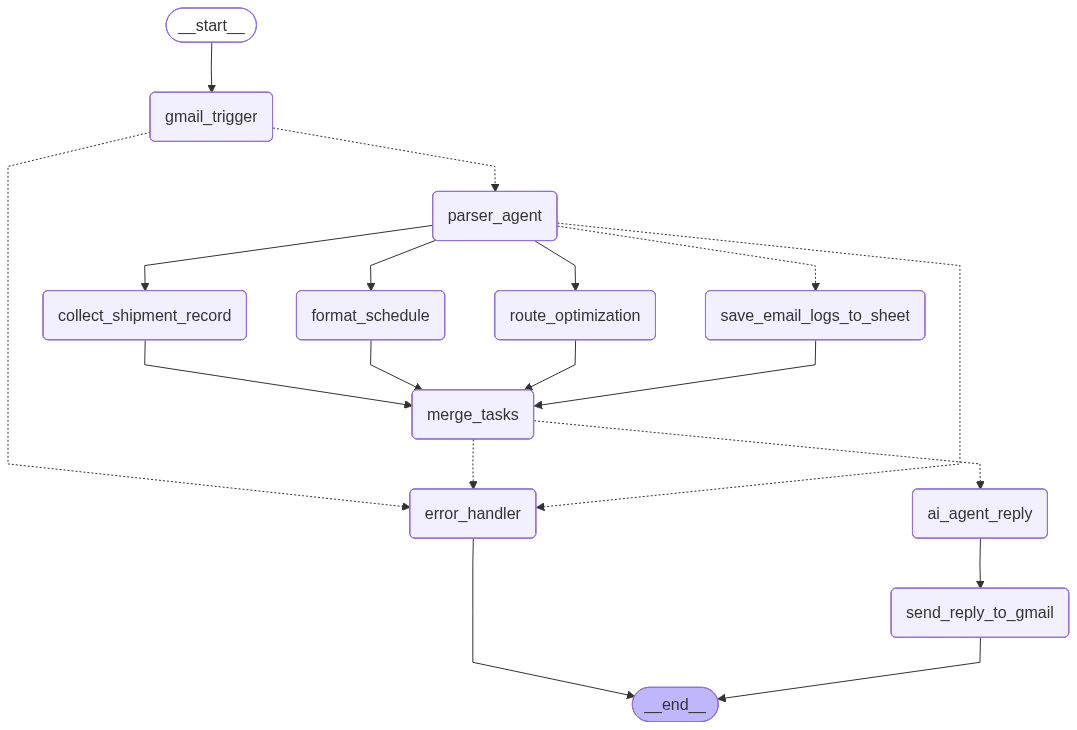

In [16]:
def build_graph():
    builder = StateGraph(LogisticsState)

    builder.add_node("gmail_trigger", gmail_trigger)
    builder.add_node("parser_agent", parser_agent)
    builder.add_node("save_email_logs_to_sheet", save_email_logs_to_sheet)
    builder.add_node("route_optimization", route_optimization)
    builder.add_node("collect_shipment_record", collect_shipment_record)
    builder.add_node("format_schedule", format_schedule)
    builder.add_node("merge_tasks", merge_tasks)
    builder.add_node("ai_agent_reply", ai_agent_reply)
    builder.add_node("send_reply_to_gmail", send_reply_to_gmail)
    builder.add_node("error_handler", error_handler)

    builder.add_edge(START, "gmail_trigger")

    builder.add_conditional_edges(
        "gmail_trigger", route_after_trigger,
        {"parser_agent": "parser_agent", "error_handler": "error_handler"},
    )

    builder.add_conditional_edges(
        "parser_agent", route_after_parse,
        {"save_email_logs_to_sheet": "save_email_logs_to_sheet", "error_handler": "error_handler"},
    )
    builder.add_edge("parser_agent", "route_optimization")
    builder.add_edge("parser_agent", "collect_shipment_record")
    builder.add_edge("parser_agent", "format_schedule")

    builder.add_edge("save_email_logs_to_sheet", "merge_tasks")
    builder.add_edge("route_optimization", "merge_tasks")
    builder.add_edge("collect_shipment_record", "merge_tasks")
    builder.add_edge("format_schedule", "merge_tasks")

    builder.add_conditional_edges(
        "merge_tasks", route_after_merge,
        {"ai_agent_reply": "ai_agent_reply", "error_handler": "error_handler"},
    )

    builder.add_edge("ai_agent_reply", "send_reply_to_gmail")
    builder.add_edge("send_reply_to_gmail", END)
    builder.add_edge("error_handler", END)

    app = builder.compile(checkpointer=MemorySaver())
    log.info("LangGraph compiled: 10 nodes, parallel fan-out after parser_agent.")
    return app


app = build_graph()
app

10: Entry Point

In [17]:
from tools.gmail_tools import poll_gmail_inbox

POLL_INTERVAL = int(os.getenv("GMAIL_POLL_INTERVAL", "60"))
GMAIL_QUERY = os.getenv("GMAIL_QUERY", "is:unread subject:collection request")

def process_email(app, raw_email: str, thread_id: str, sender_email: str) -> dict:
    config = {"configurable": {"thread_id": thread_id}}

    state: LogisticsState = {
        "raw_email_content": raw_email,
        "sender_email": sender_email,
        "thread_id": thread_id,
        "collection_request_id": "",
        "parsed_stops": [],
        "sender_company": "",
        "route_result": None,
        "reply_html_fragment": "",
        "schedule_summary": "",
        "email_log_saved": False,
        "reply_html": "",
        "error": None,
        "messages": [],
    }

    log.info("Processing email from %s (thread: %s)", sender_email, thread_id)
    result = app.invoke(state, config=config)

    if result.get("error"):
        log.error("Workflow failed [%s] for thread %s", result["error"], thread_id)
    else:
        log.info("Workflow complete. Reply sent to %s (%s)",
                 sender_email, result.get("collection_request_id", ""))

    return result


def main():
    log.info("Starting Gmail polling every %ds. Query: %r", POLL_INTERVAL, GMAIL_QUERY)
    processed_ids: set = set()

    while True:
        try:
            emails = poll_gmail_inbox.invoke({"query": GMAIL_QUERY})
            new_emails = [e for e in emails if e["message_id"] not in processed_ids]

            if new_emails:
                log.info("Found %d new email(s).", len(new_emails))

            for email in new_emails:
                processed_ids.add(email["message_id"])
                process_email(
                    app=app,
                    raw_email=email["body"],
                    thread_id=email["thread_id"],
                    sender_email=email["sender_email"],
                )

        except Exception as exc:
            log.exception("Polling error: %s", exc)

        time.sleep(POLL_INTERVAL)


main()

2026-04-12 00:26:27,499 [INFO] Starting Gmail polling every 60s. Query: 'is:unread subject:Pickup Schedule'
2026-04-12 00:26:29,554 [INFO] Found 1 new email(s).
2026-04-12 00:26:29,556 [INFO] Processing email from Anuj Mumbaikar <anuj.mumbaikar05@gmail.com> (thread: 19d7de6db017843d)
/var/folders/73/489qwk890nz19z7w2q63j4k00000gn/T/ipykernel_51555/4058878423.py:2: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = datetime.utcnow()
2026-04-12 00:26:32,739 [INFO] New request: REQ-20260411-e5f8b9 (thread: 19d7de6db017843d)
2026-04-12 00:26:39,673 [INFO] HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-12 00:26:39,705 [INFO] Parsed 3 stops from email (sender: RetailCo Pvt Ltd)
2026-04-12 00:26:39,708 [INFO] [Task C] HTML fragment built for REQ-20260411-e5f8b9 (3 stops)
2026-04-12 00:26:39,713 [

KeyboardInterrupt: 